In [13]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split

# -----------------------------
# 1️⃣ Load full clean dataset
# -----------------------------
df = pd.read_csv("full_clean.csv")

print("Total images:", len(df))
print("Unique patients:", df["PatientId"].nunique())

# -----------------------------
# 2️⃣ Split by PatientId
# -----------------------------
unique_patients = df["PatientId"].unique()

# 70% train
train_ids, temp_ids = train_test_split(
    unique_patients,
    test_size=0.30,
    random_state=42
)

# 15% val / 15% test
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=0.50,
    random_state=42
)

# -----------------------------
# 3️⃣ Create splits
# -----------------------------
train_df = df[df["PatientId"].isin(train_ids)]

train_df.to_csv("train.csv", index=False)
val_df = df[df["PatientId"].isin(val_ids)]

val_df.to_csv("valid.csv", index=False)
test_df = df[df["PatientId"].isin(test_ids)]

test_df.to_csv("test.csv", index=False)

# -----------------------------
# 4️⃣ Check sizes
# -----------------------------
print("Train images:", len(train_df))
print("Val images:", len(val_df))
print("Test images:", len(test_df))
print("Total:", len(train_df)+len(val_df)+len(test_df))

# -


Total images: 1422
Unique patients: 1319
Train images: 994
Val images: 214
Test images: 214
Total: 1422


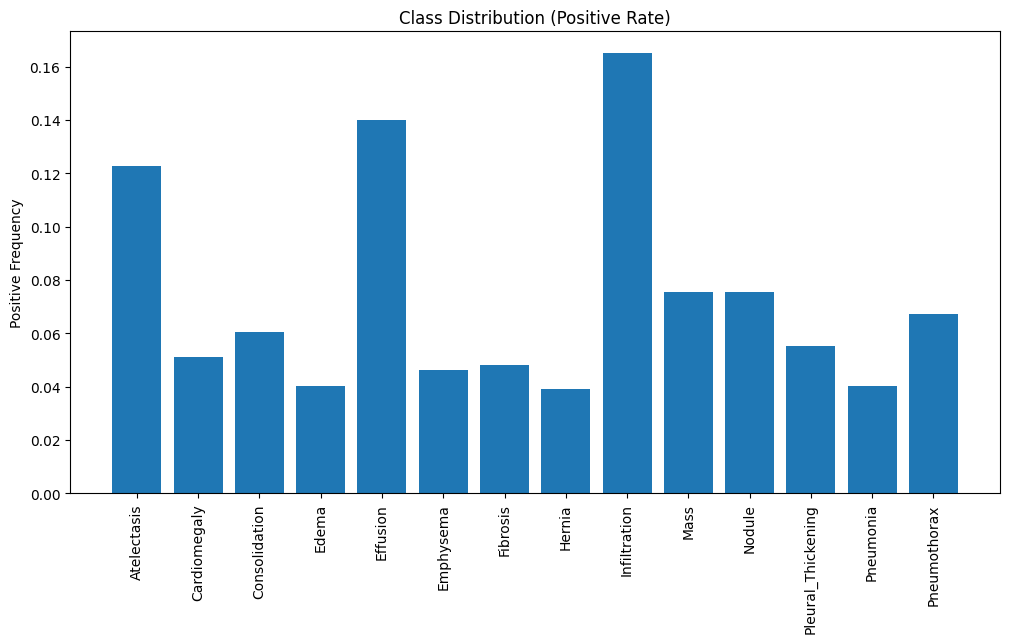

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from config import LABELS

df = pd.read_csv("train.csv")

# Positive frequency per class
pos_freq = df[LABELS].mean().values

plt.figure(figsize=(12,6))
plt.bar(LABELS, pos_freq)
plt.xticks(rotation=90)
plt.ylabel("Positive Frequency")
plt.title("Class Distribution (Positive Rate)")
plt.show()



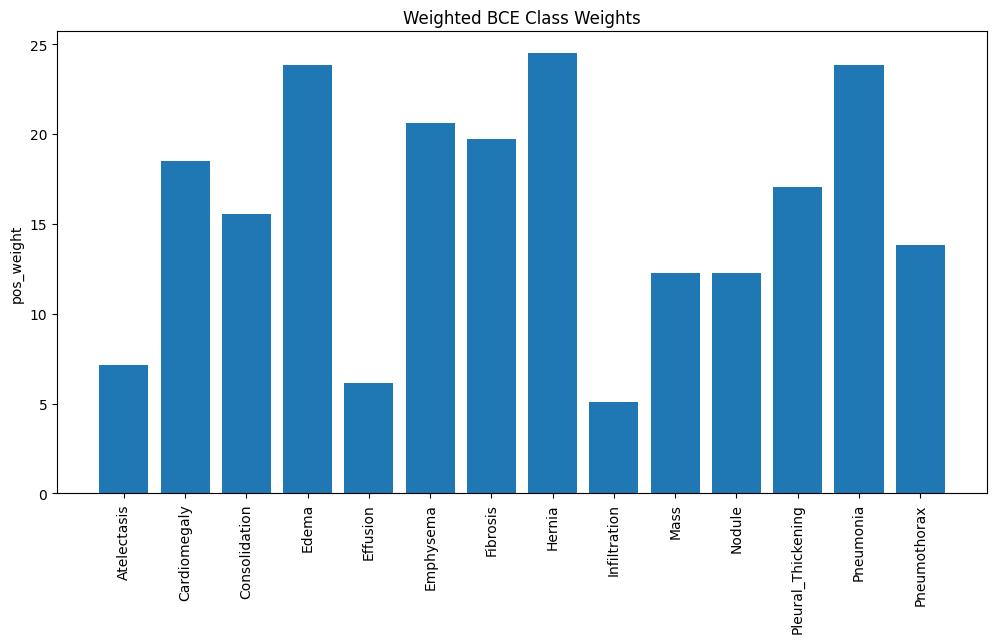

In [2]:
pos_weight = (1 - pos_freq) / (pos_freq + 1e-7)

plt.figure(figsize=(12,6))
plt.bar(LABELS, pos_weight)
plt.xticks(rotation=90)
plt.ylabel("pos_weight")
plt.title("Weighted BCE Class Weights")
plt.show()


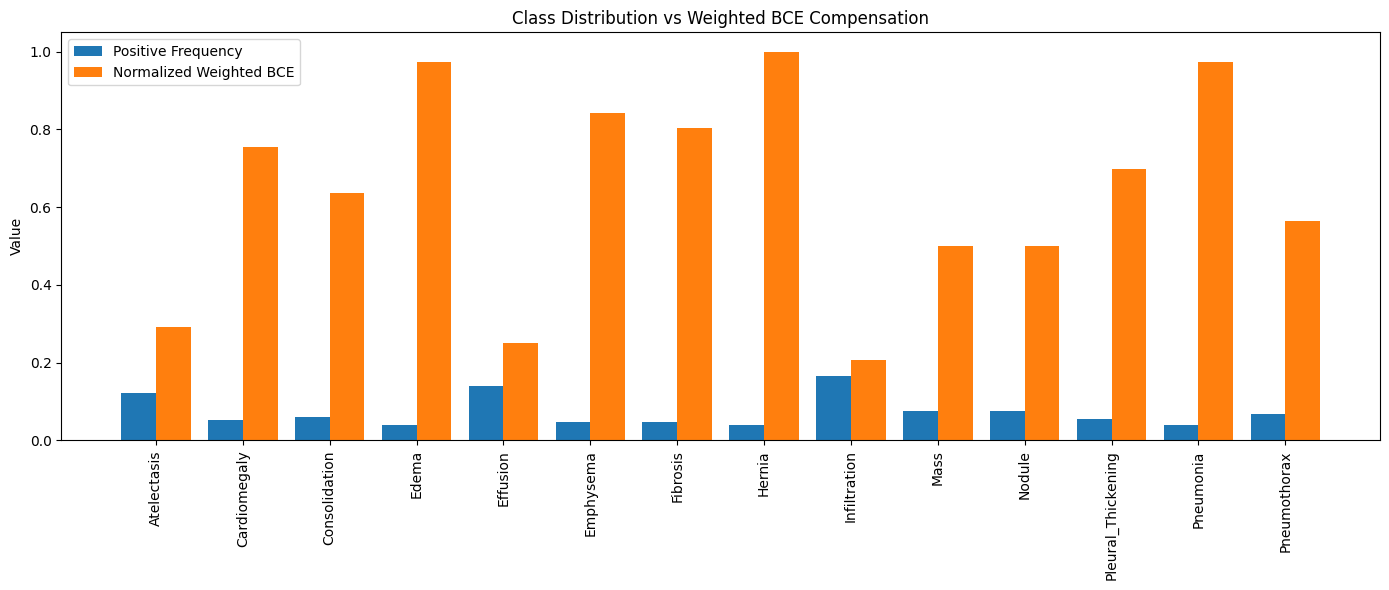

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from config import LABELS

# Load training data
df = pd.read_csv("train.csv")

# Positive frequency
pos_freq = df[LABELS].mean().values

# Weighted BCE weights
pos_weight = (1 - pos_freq) / (pos_freq + 1e-7)

# Normalize weights for visualization (so scales match)
norm_weight = pos_weight / pos_weight.max()

# X positions
x = np.arange(len(LABELS))
width = 0.4

plt.figure(figsize=(14,6))

plt.bar(x - width/2, pos_freq, width,
        label="Positive Frequency")

plt.bar(x + width/2, norm_weight, width,
        label="Normalized Weighted BCE")

plt.xticks(x, LABELS, rotation=90)
plt.ylabel("Value")
plt.title("Class Distribution vs Weighted BCE Compensation")
plt.legend()
plt.tight_layout()
plt.show()
